# Zipf's Law Analysis

This notebook analyzes the word frequency distribution of the German corpus to see if it follows [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law). Zipf's law states that given a large sample of words, the frequency of any word is inversely proportional to its rank in the frequency table.

We will perform the following steps:
1.  Load the word count data (with and without stop words).
2.  Calculate the rank of each word based on its frequency.
3.  Calculate the frequency of each word.
4.  Plot the frequency vs. rank on a log-log scale. If it follows Zipf's law, it should form a straight line.
5.  Fit the data to the function `frequency = c / (rank + b)^a` to find the exponent `a`. For a classic Zipfian distribution, `a` is close to 1.

In [9]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os

# --- Load the data ---
DATA_DIR = "../data"
with_stopwords_path = os.path.join(DATA_DIR, 'word_counts_with_stopwords.csv')
without_stopwords_path = os.path.join(DATA_DIR, 'word_counts_without_stopwords.csv')

df_with_stopwords = pd.read_csv(with_stopwords_path)
df_without_stopwords = pd.read_csv(without_stopwords_path)

# --- Define the Zipf's law function ---
def zipf_func(rank, a, b, c):
    """
    Zipf's law function: frequency = c / (rank + b)^a
    """
    return c / (rank + b)**a

# --- Process both dataframes ---
def process_dataframe(df):
    # --- Calculate Rank ---
    df['rank'] = np.arange(1, len(df) + 1)

    # --- Calculate Frequency ---
    total_words = df['count'].sum()
    df['frequency'] = df['count'] / total_words
    
    df['n x f'] = df['rank'] * df['frequency']
    
    # --- Fit the curve ---
    # We use curve_fit to find the best parameters a, b, and c.
    # We provide initial guesses for the parameters.
    initial_guesses = [1.0, 2.7, 1.0]
    params, covariance = curve_fit(zipf_func, df['rank'], df['frequency'], p0=initial_guesses)
    a, b, c = params
    
    print(f"Fitted parameters: a={a:.4f}, b={b:.4f}, c={c:.4f}")
    
    # --- Add fitted frequency to the dataframe ---
    df['fitted_frequency'] = zipf_func(df['rank'], a, b, c)
    
    return df, (a, b, c)

print("--- With Stop Words ---")
df_with_stopwords, params_with = process_dataframe(df_with_stopwords)
print("\n--- Without Stop Words ---")
df_without_stopwords, params_without = process_dataframe(df_without_stopwords)

# --- Display the results ---
print("\nDataFrame with stop words:")
display(df_with_stopwords.head())

print("\nDataFrame without stop words:")
display(df_without_stopwords.head())

--- With Stop Words ---
Fitted parameters: a=0.8672, b=-0.6206, c=0.0556

--- Without Stop Words ---
Fitted parameters: a=0.7890, b=16.1718, c=0.0318

DataFrame with stop words:


,word,count,rank,frequency,n x f,fitted_frequency
0,der,82206,1,0.129371,0.129371,0.128964
1,sein,21978,2,0.034588,0.069175,0.042103
2,ein,20131,3,0.031681,0.095043,0.026241
3,werden,14285,4,0.022481,0.089924,0.019357
4,in,12545,5,0.019743,0.098713,0.015460



DataFrame without stop words:


,word,count,rank,frequency,n x f,fitted_frequency
0,prozent,1375,1,0.004509,0.004509,0.003369
1,stehen,1292,2,0.004237,0.008473,0.003222
2,liegen,1222,3,0.004007,0.012021,0.003089
3,euro,1146,4,0.003758,0.015031,0.002967
4,finden,993,5,0.003256,0.016281,0.002856


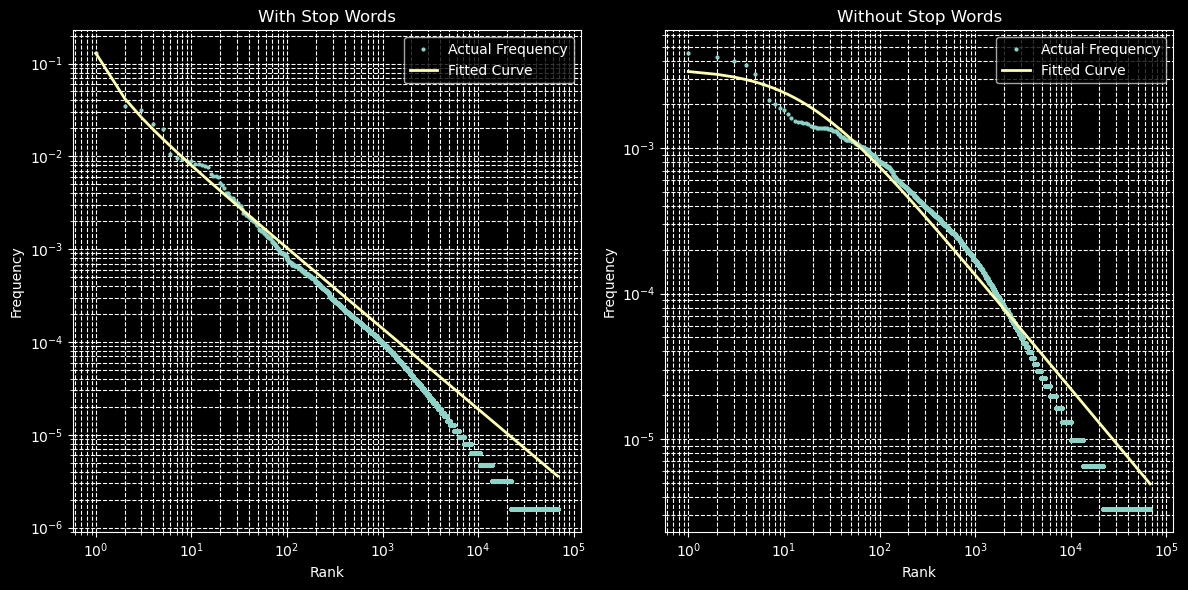

In [8]:
# --- Plot the results ---
plt.figure(figsize=(12, 6))

# --- Plot with stop words ---
plt.subplot(1, 2, 1)
plt.plot(df_with_stopwords['rank'], df_with_stopwords['frequency'], 'o', label='Actual Frequency', markersize=2)
plt.plot(df_with_stopwords['rank'], df_with_stopwords['fitted_frequency'], '-', label='Fitted Curve', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('With Stop Words')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")

# --- Plot without stop words ---
plt.subplot(1, 2, 2)
plt.plot(df_without_stopwords['rank'], df_without_stopwords['frequency'], 'o', label='Actual Frequency', markersize=2)
plt.plot(df_without_stopwords['rank'], df_without_stopwords['fitted_frequency'], '-', label='Fitted Curve', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Without Stop Words')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

## Vocabulary Size for Comprehension

A common question in language learning is how many words one needs to know to understand a certain percentage of a language. We can use our frequency data to estimate this. By calculating the cumulative frequency of words from most common to least common, we can find the point at which we've covered a specific percentage of all word occurrences in the text.

To understand 90% of the language, you need to know approximately 13339 words.
These 13339 words cover 90% of the text.


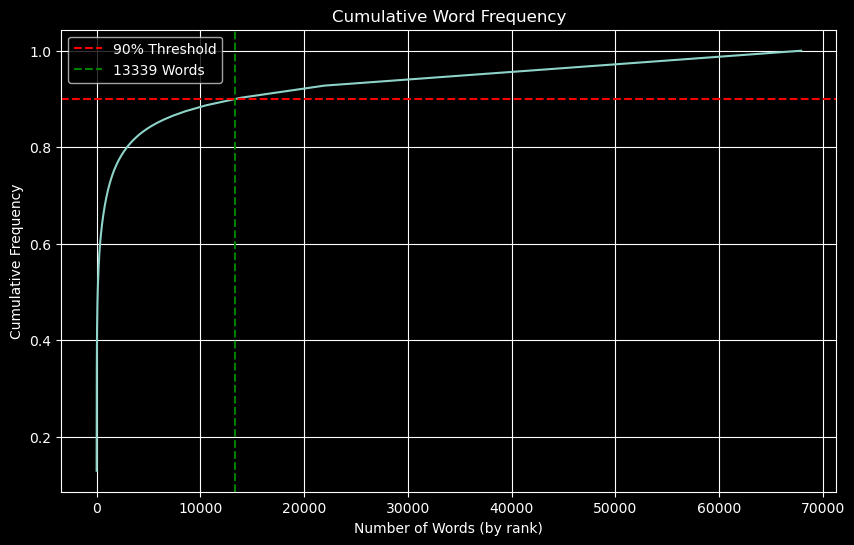

In [17]:
df = df_with_stopwords.copy()

# --- Calculate Cumulative Frequency ---
df['cumulative_frequency'] = df['frequency'].cumsum()

# --- Find the number of words to reach 90% comprehension ---
comprehension_threshold = 0.90
words_for_90_percent = df[df['cumulative_frequency'] >= comprehension_threshold].iloc[0]

num_words = int(words_for_90_percent['rank'])
actual_percentage = words_for_90_percent['cumulative_frequency']

print(f"To understand {comprehension_threshold:.0%} of the language, you need to know approximately {num_words} words.")
print(f"These {num_words} words cover {actual_percentage:.0%} of the text.")

# --- Plot Cumulative Frequency ---
plt.figure(figsize=(10, 6))
plt.plot(df_with_stopwords['rank'], df_with_stopwords['cumulative_frequency'], '-')
plt.axhline(y=comprehension_threshold, color='r', linestyle='--', label=f'{comprehension_threshold:.0%} Threshold')
plt.axvline(x=num_words, color='g', linestyle='--', label=f'{num_words} Words')
plt.title('Cumulative Word Frequency')
plt.xlabel('Number of Words (by rank)')
plt.ylabel('Cumulative Frequency')
plt.grid(True)
plt.legend()
plt.show()